# Module 4 — Q&A RAG Pipeline

**Dataset:** `heliosbrahma/mental_health_counseling_conversations` — already ingested in Qdrant Cloud  
**Embedding:** `BAAI/bge-base-en-v1.5` (768-dim)  
**Vector DB:** Qdrant Cloud (`health-counseling-dataset`, 10 042 points)  
**LLM:** Groq `openai/gpt-oss-120b` / `openai/gpt-oss-20b`

In [1]:
import os, re, uuid, time, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv

from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.http.models import VectorParams, Distance, PointStruct
from groq import Groq

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Load credentials from .env ────────────────────────────
load_dotenv('../.env')

LLM_API_KEY             = os.getenv('LLM_API_KEY')
QDRANT_CLUSTER_ENDPOINT = os.getenv('QDRANT_CLUSTER_ENDPOINT')
QDRANT_API_KEY          = os.getenv('QDRANT_API_KEY')

for var, val in [('LLM_API_KEY', LLM_API_KEY),
                 ('QDRANT_CLUSTER_ENDPOINT', QDRANT_CLUSTER_ENDPOINT),
                 ('QDRANT_API_KEY', QDRANT_API_KEY)]:
    if not val:
        raise EnvironmentError(f"{var} not found — check ../.env")

# ── Constants ─────────────────────────────────────────────
COLLECTION_NAME  = 'health-counseling-dataset'
EMBED_MODEL_NAME = 'BAAI/bge-base-en-v1.5'   # 768-dim
EMBEDDING_DIM    = 768                         # must match stored vectors
STRONG_MODEL     = 'openai/gpt-oss-120b'
WEAK_MODEL       = 'openai/gpt-oss-20b'
TOP_K            = 5
SEED             = 42
np.random.seed(SEED)

print('✅ Imports and credentials loaded.')
print(f'   Collection : {COLLECTION_NAME}')
print(f'   Embed model: {EMBED_MODEL_NAME}  ({EMBEDDING_DIM}-dim)')
print(f'   LLM        : {STRONG_MODEL}')


✅ Imports and credentials loaded.
   Collection : health-counseling-dataset
   Embed model: BAAI/bge-base-en-v1.5  (768-dim)
   LLM        : openai/gpt-oss-120b


## 1. Verify Qdrant Collection
The data was already embedded and uploaded. We verify here.

In [2]:
qdrant_client = QdrantClient(
    url     = QDRANT_CLUSTER_ENDPOINT,
    api_key = QDRANT_API_KEY,
    timeout = 30
)

info = qdrant_client.get_collection(COLLECTION_NAME)
print(f'Collection : {COLLECTION_NAME}')
print(f'Points     : {info.points_count:,}')
print(f'Vector dim : {info.config.params.vectors.size}')
print(f'Distance   : {info.config.params.vectors.distance}')
assert info.config.params.vectors.size == EMBEDDING_DIM, \
    f'Dimension mismatch! stored={info.config.params.vectors.size}, expected={EMBEDDING_DIM}'
print('✅ Dimension check passed.')


Collection : health-counseling-dataset
Points     : 10,042
Vector dim : 768
Distance   : Cosine
✅ Dimension check passed.


## 2. Load Embedding Model

In [3]:
import torch
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=device)
# Quick sanity check — embedding dim must match collection
test_vec = embed_model.encode('test', normalize_embeddings=True)
assert len(test_vec) == EMBEDDING_DIM, f'Dim mismatch: {len(test_vec)} vs {EMBEDDING_DIM}'
print(f'✅ Embedding model ready. Vector dim: {len(test_vec)}')


Using device: mps


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5946.53it/s]

✅ Embedding model ready. Vector dim: 768


## 3. Exploratory Data Analysis (sampled from Qdrant)

In [4]:
# Sample 200 documents from Qdrant for EDA
sample_vec = embed_model.encode('mental health anxiety depression', normalize_embeddings=True).tolist()
sample_pts  = qdrant_client.query_points(
    collection_name = COLLECTION_NAME,
    query           = sample_vec,
    limit           = 200,
    with_payload    = True,
).points

rows = []
for pt in sample_pts:
    p = pt.payload or {}
    ctx  = p.get('context', '') or p.get('chunk', '')
    resp = p.get('response', '') or ''
    rows.append({'patient_text': ctx, 'counselor_text': resp, 'score': pt.score})

df = pd.DataFrame(rows)
df['patient_words']   = df['patient_text'].str.split().str.len()
df['counselor_words'] = df['counselor_text'].str.split().str.len()

print(f'Sampled {len(df)} documents from Qdrant')
print(df[['patient_words','counselor_words']].describe().round(1))
df[['patient_text','counselor_text']].head(3)


Sampled 200 documents from Qdrant
       patient_words  counselor_words
count          200.0            200.0
mean            56.2            188.3
std             41.3             78.0
min             11.0             25.0
25%             30.0            107.2
50%             41.0            217.0
75%             70.0            258.0
max            192.0            278.0


,patient_text,counselor_text
0,I'm in my late teens and live with my dad. Th...,Although some people managing depression feel ...
1,I'm in my late teens and live with my dad. The...,Although some people managing depression feel ...
2,I’m facing severe depression and anxiety and I...,Wanting to make changes and asking for assista...


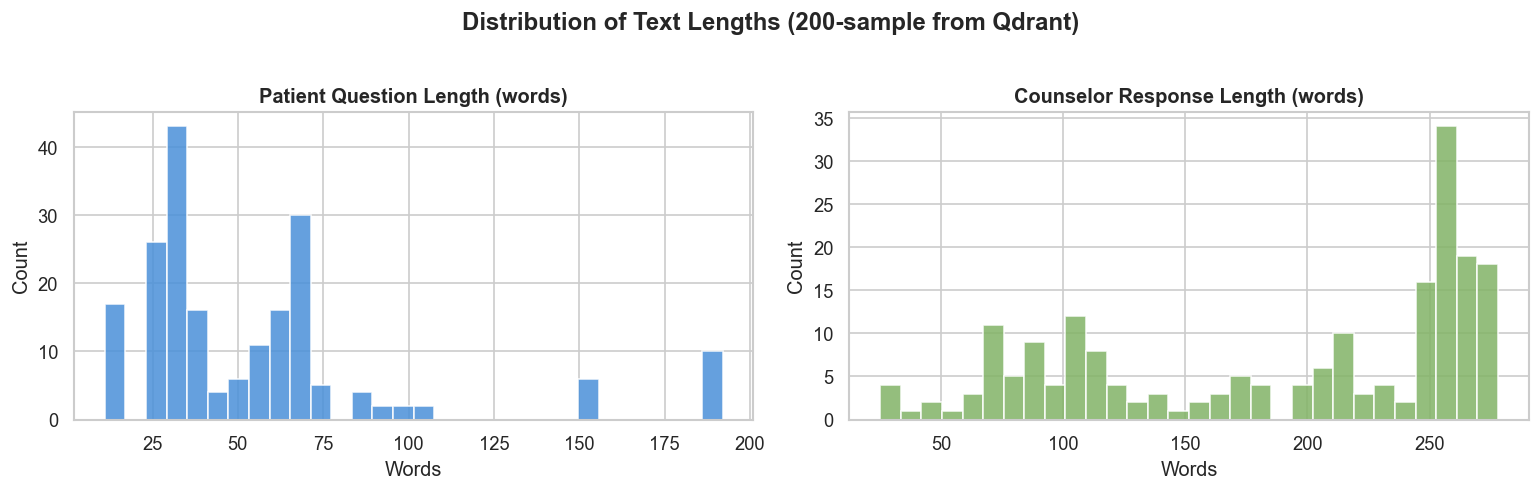

Mean patient words   : 56.2
Mean counselor words : 188.3


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['patient_words'].dropna(),   bins=30, color='#4A90D9', edgecolor='white', alpha=.85)
axes[0].set_title('Patient Question Length (words)', fontweight='bold')
axes[0].set_xlabel('Words'); axes[0].set_ylabel('Count')

axes[1].hist(df['counselor_words'].dropna(), bins=30, color='#82B366', edgecolor='white', alpha=.85)
axes[1].set_title('Counselor Response Length (words)', fontweight='bold')
axes[1].set_xlabel('Words'); axes[1].set_ylabel('Count')

plt.suptitle('Distribution of Text Lengths (200-sample from Qdrant)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(f'Mean patient words   : {df.patient_words.mean():.1f}')
print(f'Mean counselor words : {df.counselor_words.mean():.1f}')


## 4. Chunking Strategy
Each Q&A pair was stored as a single chunk with format:
```
Patient: <question text>
Counselor: <response text>
```
For long responses (>350 words), overlapping 100-word sub-chunks with 20-word overlap were used.

## 5. Retrieval Testing

In [6]:
def retrieve_chunks(query: str, top_k: int = TOP_K) -> list[dict]:
    """Embed query and retrieve top-k passages from Qdrant."""
    query_vec = embed_model.encode(query, normalize_embeddings=True).tolist()
    results   = qdrant_client.query_points(
        collection_name = COLLECTION_NAME,
        query           = query_vec,
        limit           = top_k,
        with_payload    = True,
    ).points
    docs = []
    for pt in results:
        p    = pt.payload or {}
        ctx  = p.get('context',  '') or p.get('chunk', '')
        resp = p.get('response', '') or ''
        text = f'Patient: {ctx}\nCounselor: {resp}' if ctx else p.get('chunk','')
        docs.append({'text': text, 'score': round(pt.score, 4),
                     'context': ctx[:200], 'response': resp[:200]})
    return docs

# Test retrieval on 3 queries
test_queries = [
    'How do I manage anxiety at night?',
    'I feel hopeless and cannot sleep',
    'Panic attack coping strategies',
]
for q in test_queries:
    docs = retrieve_chunks(q, top_k=3)
    print(f'Q: {q}')
    for i, d in enumerate(docs, 1):
        print(f'  [{i}] score={d["score"]:.3f}  {d["context"][:80]}...')
    print()


Q: How do I manage anxiety at night?
  [1] score=0.734  Sometimes, I'm fine and can go out or meet people, but other days, my heart race...
  [2] score=0.734  Sometimes, I'm fine and can go out or meet people, but other days, my heart race...
  [3] score=0.726  I have twin toddlers. I experienced a death of loved one prior to giving birth. ...



Q: I feel hopeless and cannot sleep
  [1] score=0.779  I'm going through some things with my feelings and myself. I barely sleep and I ...
  [2] score=0.768  I'm going through some things with my feelings and myself. I barely sleep and I ...
  [3] score=0.752  I have friends, family, I live in a good home, I go to a nice high school, and I...



Q: Panic attack coping strategies
  [1] score=0.757  I shake and have panic attacks....
  [2] score=0.757  I shake and have panic attacks....
  [3] score=0.752  I get so much anxiety, and I don’t know why. I feel like I can’t do anything by ...



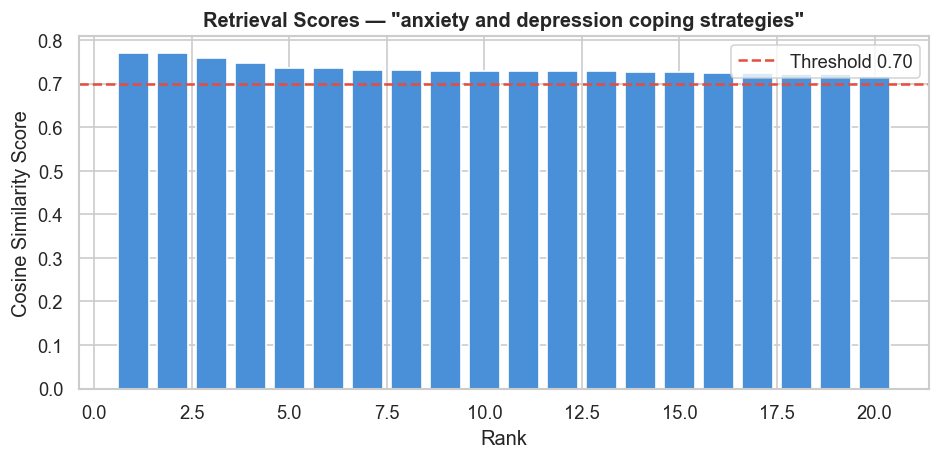

Top-5 scores: [0.7704, 0.7704, 0.7581, 0.7483, 0.7352]


In [7]:
# Visualise relevance score distribution
query_viz = 'anxiety and depression coping strategies'
docs_viz  = retrieve_chunks(query_viz, top_k=20)
scores    = [d['score'] for d in docs_viz]

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(scores)+1), scores, color='#4A90D9', edgecolor='white')
plt.axhline(0.7, color='#E74C3C', linestyle='--', label='Threshold 0.70')
plt.xlabel('Rank'); plt.ylabel('Cosine Similarity Score')
plt.title(f'Retrieval Scores — "{query_viz}"', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Top-5 scores: {scores[:5]}')


## 6. Emotion-Aware Prompt Engineering

In [8]:
EMOTION_TONE_MAP = {
    'sadness' : 'deeply compassionate and validating — acknowledge the pain directly',
    'fear'    : 'calm, reassuring, and grounding — provide steady support',
    'anger'   : 'empathetic and de-escalating — validate feelings without amplifying',
    'love'    : 'warm and affirming — celebrate connection and care',
    'joy'     : 'positive and encouraging — build on existing strengths',
    'surprise': 'clarifying and gently supportive — help process the unexpected',
    'neutral' : 'balanced and professional — informative with warmth',
}

SYSTEM_PROMPT = """You are a compassionate mental health support assistant.
Your role: empathetic, grounded, and helpful responses to people seeking support.

RULES:
1. Base your answer PRIMARILY on the provided context passages.
2. Respond in the SAME LANGUAGE as the user message.
3. Match the empathy tone instruction.
4. NEVER diagnose or prescribe medication.
5. Encourage professional help for serious concerns.
6. Keep responses warm and actionable (3-6 sentences).
7. Never say: 'Just think positive', 'Others have it worse', 'Stop overthinking'."""

RAG_TEMPLATE = """{system}

USER EMOTION: {emotion} — use a {tone} tone.
RESPOND IN: {language}

KNOWLEDGE BASE CONTEXT:
{context}

USER QUESTION: {question}

RESPONSE:"""

print('Emotion tone map:')
for emo, tone in EMOTION_TONE_MAP.items():
    print(f'  {emo:<10} → {tone[:60]}')


Emotion tone map:
  sadness    → deeply compassionate and validating — acknowledge the pain d
  fear       → calm, reassuring, and grounding — provide steady support
  anger      → empathetic and de-escalating — validate feelings without amp
  love       → warm and affirming — celebrate connection and care
  joy        → positive and encouraging — build on existing strengths
  surprise   → clarifying and gently supportive — help process the unexpect
  neutral    → balanced and professional — informative with warmth


## 7. Full RAG Pipeline Demo

In [9]:
groq_client = Groq(api_key=LLM_API_KEY)

def run_rag_pipeline(
    user_query : str,
    emotion    : str  = 'neutral',
    language   : str  = 'English',
    top_k      : int  = 5,
    verbose    : bool = True
) -> dict:
    t0 = time.time()
    
    # 1. Retrieve
    docs    = retrieve_chunks(user_query, top_k=top_k)
    context = '\n\n---\n\n'.join(
        f'[Relevance {d["score"]:.2f}]\n{d["text"]}' for d in docs
    )
    
    # 2. Build prompt
    tone   = EMOTION_TONE_MAP.get(emotion, EMOTION_TONE_MAP['neutral'])
    prompt = RAG_TEMPLATE.format(
        system=SYSTEM_PROMPT, emotion=emotion, tone=tone,
        language=language, context=context, question=user_query
    )
    
    # 3. Generate
    r = groq_client.chat.completions.create(
        model=STRONG_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.65, max_tokens=600
    )
    response = r.choices[0].message.content.strip()
    elapsed  = round((time.time() - t0) * 1000, 1)
    
    if verbose:
        print(f'Q : {user_query}')
        print(f'A : {response}')
        print(f'   [emotion={emotion}  docs={len(docs)}  {elapsed}ms]')
        print()
    
    return {'response': response, 'docs': docs, 'elapsed_ms': elapsed}

# --- 5 end-to-end examples ---
examples = [
    {'query': "I've been feeling extremely anxious lately and can't calm down.",   'emotion': 'fear'},
    {'query': 'I feel so sad and hopeless. Nothing seems worth it anymore.',         'emotion': 'sadness'},
    {'query': 'I keep having panic attacks at work. What can I do?',                 'emotion': 'fear'},
    {'query': 'I feel angry all the time and I don\'t know why.',                   'emotion': 'anger'},
    {'query': 'I haven\'t been able to sleep for weeks because of stress.',         'emotion': 'sadness'},
]
for ex in examples:
    _ = run_rag_pipeline(ex['query'], emotion=ex['emotion'])


Q : I've been feeling extremely anxious lately and can't calm down.
A : I hear how overwhelming the anxiety feels right now, and it’s okay to give yourself permission to pause and breathe. Try a simple grounding exercise: notice five things you can see, four you can touch, three you can hear, two you can smell, and one you can taste, then take three slow, deep breaths focusing on the rise and fall of your chest. It can also help to write down what’s on your mind for a few minutes, letting the thoughts flow without judging them. If the anxiety continues to feel unmanageable, consider reaching out to a therapist or counselor—you deserve a safe space where you can explore these feelings and learn tools that work for you. Remember, you’re not alone, and taking even a small step toward support is a sign of strength.
   [emotion=fear  docs=5  2037.9ms]



Q : I feel so sad and hopeless. Nothing seems worth it anymore.
A : I hear how deeply painful and empty things feel for you right now, and it’s completely understandable to feel that way when hope seems out of reach. You deserve a space where you can be heard without judgment, so consider reaching out to a trusted friend, family member, or a mental‑health professional who can hold that space for you. Even small acts—like stepping outside for fresh air, writing down one thing you’re grateful for, or simply breathing slowly for a few minutes—can create tiny moments of relief. If thoughts of hopelessness become overwhelming, please know that help is available right away through crisis hotlines or local services. You are not alone, and taking one gentle step toward support can begin to shift the weight you’re carrying.
   [emotion=sadness  docs=5  1716.7ms]



Q : I keep having panic attacks at work. What can I do?
A : I’m really sorry you’re dealing with panic attacks at work—it can feel overwhelming, but there are some simple steps you can try in the moment to help calm your body. When you notice the surge, try grounding yourself by counting backward from 100 in sevens or naming a city for each letter of the alphabet; keeping a small ice pack or a cold bottle nearby to hold can also give your nervous system a gentle reset. Practice slow, belly‑focused breathing (inhale for four counts, hold for two, exhale for six) a few times a day, and consider adding a short walk, gentle stretching, or a brief meditation break during breaks. If these attacks continue, reaching out to a therapist who can teach you longer‑term coping tools—like cognitive reframing, yoga, or a personalized breathing routine—can make a big difference. You deserve support, and taking these small actions now can help you feel steadier while you work toward that help.
   [emot

Q : I feel angry all the time and I don't know why.
A : I hear how overwhelming it feels to have anger showing up constantly, even when you don’t know what’s behind it. It can help to pause and notice what else you might be feeling at the same time—frustration, hurt, or a sense of powerlessness often rides alongside anger. Try keeping a brief journal for a week, noting the time of day, how well you slept, and any triggers or other emotions that appear; patterns may start to emerge and point toward underlying needs. If you notice moments when the anger eases, ask yourself what was different in those situations—they can give clues about what supports you. Speaking with a therapist can provide a safe space to explore these hidden feelings and develop new ways to manage them, so consider reaching out for professional support.
   [emotion=anger  docs=5  3276.9ms]



Q : I haven't been able to sleep for weeks because of stress.
A : I hear how overwhelming it feels to lie awake night after night while the stress keeps pressing on you—​it’s an exhausting and painful place to be. Try giving yourself a few minutes each evening to focus on slow, deep breaths or a gentle guided‑meditation; even a short, calming routine can signal your body that it’s safe to let go. If you’re a student, the campus counseling center often offers a handful of free sessions that can help you untangle the weight you’re carrying. Reaching out to a therapist or a local support group can also give you a steady, compassionate ear and practical tools for managing both the stress and the sleeplessness. You deserve relief, and taking one small step toward professional support can begin to ease the night’s grip.
   [emotion=sadness  docs=5  20288.9ms]



## 8. Manual Evaluation

                                        Query  Docs Retrieved  Top Score  Has Context  Has Response
            How do I cope with panic attacks?               5      0.752         True          True
            I feel depressed and unmotivated.               5      0.766         True          True
What are some relaxation techniques for anxie               5      0.810         True          True


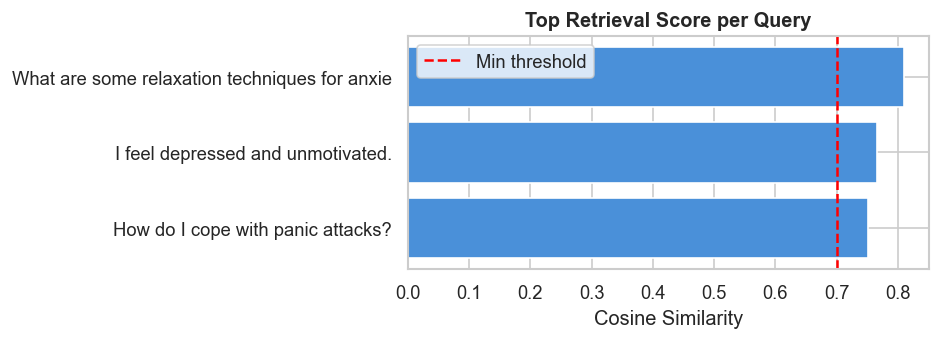

In [10]:
eval_queries = [
    'How do I cope with panic attacks?',
    'I feel depressed and unmotivated.',
    'What are some relaxation techniques for anxiety?',
]
eval_results = []
for q in eval_queries:
    docs  = retrieve_chunks(q, top_k=5)
    top_s = docs[0]['score'] if docs else 0
    eval_results.append({
        'Query'         : q[:45],
        'Docs Retrieved': len(docs),
        'Top Score'     : round(top_s, 3),
        'Has Context'   : bool(docs[0]['context']) if docs else False,
        'Has Response'  : bool(docs[0]['response']) if docs else False,
    })

eval_df = pd.DataFrame(eval_results)
print(eval_df.to_string(index=False))

# Plot top scores
plt.figure(figsize=(8, 3))
plt.barh(eval_df['Query'], eval_df['Top Score'], color='#4A90D9')
plt.axvline(0.7, color='red', linestyle='--', label='Min threshold')
plt.xlabel('Cosine Similarity'); plt.title('Top Retrieval Score per Query', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()


## 9. Production Integration Module

In [11]:
# rag_pipeline.py — production class (mirrors src/modules/rag_pipeline.py)

class RAGPipeline:
    """
    Production RAG pipeline for the mental health chatbot.

    Usage
    -----
    >>> rag = RAGPipeline()
    >>> result = rag.answer("I feel anxious", emotion="fear")
    >>> print(result["response"])
    """

    def __init__(self,
                 groq_api_key=None, qdrant_url=None, qdrant_api_key=None,
                 embed_model_name=EMBED_MODEL_NAME):
        import os, torch
        from groq import Groq
        from qdrant_client import QdrantClient
        from sentence_transformers import SentenceTransformer

        groq_key = groq_api_key  or os.getenv("LLM_API_KEY")
        q_url    = qdrant_url    or os.getenv("QDRANT_CLUSTER_ENDPOINT")
        q_key    = qdrant_api_key or os.getenv("QDRANT_API_KEY")

        dev = "mps" if torch.backends.mps.is_available() else "cpu"
        self.groq     = Groq(api_key=groq_key)
        self.qdrant   = QdrantClient(url=q_url, api_key=q_key)
        self.embedder = SentenceTransformer(embed_model_name, device=dev)

    def retrieve(self, query: str, top_k: int = 5) -> list[dict]:
        vec  = self.embedder.encode(query, normalize_embeddings=True).tolist()
        hits = self.qdrant.query_points(
            collection_name=COLLECTION_NAME, query=vec,
            limit=top_k, with_payload=True
        ).points
        docs = []
        for h in hits:
            p    = h.payload or {}
            ctx  = p.get("context","") or p.get("chunk","")
            resp = p.get("response","")
            text = f"Patient: {ctx}\nCounselor: {resp}" if ctx else ctx
            docs.append({"text": text, "score": round(h.score,4),
                          "context": ctx, "response": resp})
        return docs

    def answer(self, question: str, emotion: str = "neutral",
               language: str = "English", top_k: int = 5) -> dict:
        docs    = self.retrieve(question, top_k=top_k)
        ctx_str = "\n\n---\n\n".join(
            f"[{d['score']:.2f}]\n{d['text']}" for d in docs
        ) if docs else "No relevant passages found."
        tone   = EMOTION_TONE_MAP.get(emotion, EMOTION_TONE_MAP["neutral"])
        prompt = RAG_TEMPLATE.format(
            system=SYSTEM_PROMPT, emotion=emotion, tone=tone,
            language=language, context=ctx_str, question=question
        )
        r = self.groq.chat.completions.create(
            model=STRONG_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.65, max_tokens=600
        )
        return {"response": r.choices[0].message.content.strip(),
                "sources": docs, "model": STRONG_MODEL}

# Quick test
rag = RAGPipeline()
result = rag.answer("How can I manage stress?", emotion="fear")
print(f"Response ({len(result['response'])} chars):")
print(result["response"][:300])
print(f"\nSources: {result['sources'][0]['score']:.3f} top score")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5253.70it/s]

Response (708 chars):
I hear how overwhelming things feel right now, and it’s okay to take a moment for yourself. Start with a simple daily ritual—perhaps set a brief intention each morning and, at the end of the workday, clear your space and write down tomorrow’s top tasks to signal a clear transition. Make sure to prot

Sources: 0.825 top score
